In [1]:
print("="*60)
print("REAL QUANTUM RNA OPTIMIZATION")
print("Moderna Research Project")
print("="*60)

!pip -q install qiskit qiskit-algorithms qiskit-optimization ViennaRNA pandas numpy matplotlib networkx

REAL QUANTUM RNA OPTIMIZATION
Moderna Research Project


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import RNA

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
def generate_rna(length):
    bases = ['A', 'U', 'C', 'G']
    return ''.join(random.choice(bases) for _ in range(length))

rna = generate_rna(12)

print("RNA Sequence")
print(rna)
print("Length:", len(rna))

RNA Sequence
AUUCCCGUCAAC
Length: 12


In [4]:
structure, mfe = RNA.fold(rna)

print("="*50)
print("ViennaRNA Prediction")
print("="*50)

print("Sequence : ", rna)
print("Structure:", structure)
print("MFE      :", mfe)

ViennaRNA Prediction
Sequence :  AUUCCCGUCAAC
Structure: ............
MFE      : 0.0


In [5]:
valid_pairs = {
    ('A','U'),
    ('U','A'),
    ('C','G'),
    ('G','C'),
    ('G','U'),
    ('U','G')
}

possible_pairs = []

for i in range(len(rna)):
    for j in range(i+4, len(rna)):   # minimum loop length = 4
        if (rna[i], rna[j]) in valid_pairs:
            possible_pairs.append((i, j))

print("Possible Base Pairs")
print("-"*40)

for pair in possible_pairs:
    print(pair)

Possible Base Pairs
----------------------------------------
(0, 7)
(1, 6)
(1, 9)
(1, 10)
(2, 6)
(2, 9)
(2, 10)
(6, 11)


In [6]:
print("="*60)
print("Binary Decision Variables")
print("="*60)

variables = {}

for index, pair in enumerate(possible_pairs):
    variables[index] = pair
    print(f"x{index} ---> {pair}")

Binary Decision Variables
x0 ---> (0, 7)
x1 ---> (1, 6)
x2 ---> (1, 9)
x3 ---> (1, 10)
x4 ---> (2, 6)
x5 ---> (2, 9)
x6 ---> (2, 10)
x7 ---> (6, 11)


In [7]:
n = len(possible_pairs)

Q = np.zeros((n, n))

print("Creating QUBO Matrix...")

for i in range(n):
    Q[i][i] = -1

Creating QUBO Matrix...


In [8]:
for i in range(n):

    a, b = possible_pairs[i]

    for j in range(i+1, n):

        c, d = possible_pairs[j]

        if len({a,b,c,d}) < 4:
            Q[i][j] = 2
            Q[j][i] = 2

In [9]:
import pandas as pd

qubo_df = pd.DataFrame(Q)

print("Generated QUBO Matrix")

display(qubo_df)

Generated QUBO Matrix


,0,1,2,3,4,5,6,7
0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,-1.0,2.0,2.0,2.0,0.0,0.0,2.0
2,0.0,2.0,-1.0,2.0,0.0,2.0,0.0,0.0
3,0.0,2.0,2.0,-1.0,0.0,0.0,2.0,0.0
4,0.0,2.0,0.0,0.0,-1.0,2.0,2.0,2.0
5,0.0,0.0,2.0,0.0,2.0,-1.0,2.0,0.0
6,0.0,0.0,0.0,2.0,2.0,2.0,-1.0,0.0
7,0.0,2.0,0.0,0.0,2.0,0.0,0.0,-1.0


In [10]:
print("Matrix Shape:", Q.shape)

print("\nFirst Five Rows\n")

print(Q[:5,:5])

Matrix Shape: (8, 8)

First Five Rows

[[-1.  0.  0.  0.  0.]
 [ 0. -1.  2.  2.  2.]
 [ 0.  2. -1.  2.  0.]
 [ 0.  2.  2. -1.  0.]
 [ 0.  2.  0.  0. -1.]]


In [11]:
import itertools

print("="*60)
print("CLASSICAL OPTIMIZATION OF THE RNA QUBO")
print("="*60)

best_energy = float("inf")
best_solution = None

n = len(possible_pairs)

# Brute force only for small problems
if n <= 20:

    for bits in itertools.product([0,1], repeat=n):

        x = np.array(bits)

        energy = x.T @ Q @ x

        if energy < best_energy:
            best_energy = energy
            best_solution = bits

    print("\nOptimal Binary Solution")
    print(best_solution)

    print("\nMinimum QUBO Energy")
    print(best_energy)

else:

    print("Too many variables for brute force.")

CLASSICAL OPTIMIZATION OF THE RNA QUBO

Optimal Binary Solution
(1, 0, 0, 1, 0, 1, 0, 1)

Minimum QUBO Energy
-4.0


In [12]:
print("="*60)
print("SELECTED RNA BASE PAIRS")
print("="*60)

selected_pairs = []

for i, bit in enumerate(best_solution):

    if bit == 1:

        selected_pairs.append(possible_pairs[i])

print(selected_pairs)

SELECTED RNA BASE PAIRS
[(0, 7), (1, 10), (2, 9), (6, 11)]


In [13]:
print("="*60)
print("COMPARISON")
print("="*60)

print("ViennaRNA Structure")
print(structure)

print("\nViennaRNA MFE")
print(mfe)

print("\nQUBO Energy")
print(best_energy)

print("\nPredicted Base Pairs")
print(selected_pairs)

COMPARISON
ViennaRNA Structure
............

ViennaRNA MFE
0.0

QUBO Energy
-4.0

Predicted Base Pairs
[(0, 7), (1, 10), (2, 9), (6, 11)]


In [14]:
from qiskit_optimization import QuadraticProgram

qp = QuadraticProgram()

print("QuadraticProgram created successfully!")

QuadraticProgram created successfully!


In [15]:
num_vars = len(possible_pairs)

for i in range(num_vars):
    qp.binary_var(name=f"x{i}")

print(f"{num_vars} binary variables created.")

8 binary variables created.


In [16]:
linear = {}
quadratic = {}

for i in range(num_vars):

    linear[f"x{i}"] = Q[i][i]

    for j in range(i+1, num_vars):

        if Q[i][j] != 0:
            quadratic[(f"x{i}", f"x{j}")] = Q[i][j]

qp.minimize(
    linear=linear,
    quadratic=quadratic
)

print("Objective function added successfully!")

Objective function added successfully!


In [17]:
print(qp)

minimize 2*x1*x2 + 2*x1*x3 + 2*x1*x4 + 2*x1*x7 + 2*x2*x3 + 2*x2*x5 + 2*x3*x6 + 2*x4*x5 + 2*x4*x6 + 2*x4*x7 + 2*x5*x6 - x0 - x1 - x2 - x3 - x4 - x5 - x6 - x7 (8 variables, 0 constraints, '')


In [18]:
print("="*60)
print("Optimization Summary")
print("="*60)

print("Variables :", qp.get_num_vars())
print("Constraints :", qp.get_num_linear_constraints())
print("Objective Sense :", qp.objective.sense)

Optimization Summary
Variables : 8
Constraints : 0
Objective Sense : ObjSense.MINIMIZE


In [19]:
# Convert Quadratic Program to Ising Hamiltonian

operator, offset = qp.to_ising()

print("="*60)
print("ISING HAMILTONIAN")
print("="*60)

print(operator)
print("\nOffset:", offset)

ISING HAMILTONIAN
SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIZIIZII', 'IZIIZIII', 'IIZZIIII', 'IZIZIIII', 'ZIIZIIII', 'IZZIIIII'],
              coeffs=[ 0.5+0.j, -1.5+0.j, -1. +0.j, -1. +0.j, -1.5+0.j, -1. +0.j, -1. +0.j,
 -0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,
  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j])

Offset: 1.5


In [20]:
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA

print("QAOA imported successfully!")

QAOA imported successfully!


In [21]:
optimizer = COBYLA(maxiter=100)

sampler = StatevectorSampler()

qaoa = QAOA(
    sampler=sampler,
    optimizer=optimizer,
    reps=2
)

print("QAOA Created Successfully!")

QAOA Created Successfully!


In [22]:
from qiskit_optimization import QuadraticProgram

qp = QuadraticProgram()

print("QuadraticProgram created successfully!")

QuadraticProgram created successfully!


In [23]:
num_vars = len(possible_pairs)

for i in range(num_vars):
    qp.binary_var(name=f"x{i}")

print(f"{num_vars} binary variables created.")

8 binary variables created.


In [24]:
linear = {}
quadratic = {}

for i in range(num_vars):

    linear[f"x{i}"] = Q[i][i]

    for j in range(i+1, num_vars):

        if Q[i][j] != 0:
            quadratic[(f"x{i}", f"x{j}")] = Q[i][j]

qp.minimize(
    linear=linear,
    quadratic=quadratic
)

print("Objective function added successfully!")

Objective function added successfully!


In [25]:
print(qp)

minimize 2*x1*x2 + 2*x1*x3 + 2*x1*x4 + 2*x1*x7 + 2*x2*x3 + 2*x2*x5 + 2*x3*x6 + 2*x4*x5 + 2*x4*x6 + 2*x4*x7 + 2*x5*x6 - x0 - x1 - x2 - x3 - x4 - x5 - x6 - x7 (8 variables, 0 constraints, '')


In [26]:
print("="*60)
print("Optimization Summary")
print("="*60)

print("Variables :", qp.get_num_vars())
print("Constraints :", qp.get_num_linear_constraints())
print("Objective Sense :", qp.objective.sense)

Optimization Summary
Variables : 8
Constraints : 0
Objective Sense : ObjSense.MINIMIZE


In [27]:
# Convert Quadratic Program to Ising Hamiltonian

operator, offset = qp.to_ising()

print("="*60)
print("ISING HAMILTONIAN")
print("="*60)

print(operator)
print("\nOffset:", offset)

ISING HAMILTONIAN
SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIZIIZII', 'IZIIZIII', 'IIZZIIII', 'IZIZIIII', 'ZIIZIIII', 'IZZIIIII'],
              coeffs=[ 0.5+0.j, -1.5+0.j, -1. +0.j, -1. +0.j, -1.5+0.j, -1. +0.j, -1. +0.j,
 -0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,
  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j])

Offset: 1.5


In [28]:
from qiskit_optimization.algorithms import MinimumEigenOptimizer

qaoa_optimizer = MinimumEigenOptimizer(qaoa)

result = qaoa_optimizer.solve(qp)

print("="*60)
print("QAOA RESULT")
print("="*60)

print(result)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


QAOA RESULT
fval=-4.0, x0=1.0, x1=0.0, x2=0.0, x3=1.0, x4=0.0, x5=1.0, x6=0.0, x7=1.0, status=SUCCESS


In [29]:
print("="*60)
print("SELECTED BASE PAIRS (QAOA)")
print("="*60)

selected_pairs_qaoa = []

for i, value in enumerate(result.x):
    if round(value) == 1:
        selected_pairs_qaoa.append(possible_pairs[i])

print(selected_pairs_qaoa)

SELECTED BASE PAIRS (QAOA)
[(0, 7), (1, 10), (2, 9), (6, 11)]


In [30]:
print("="*60)
print("FINAL COMPARISON")
print("="*60)

print("Classical Best Energy :", best_energy)
print("QAOA Objective Value  :", result.fval)

print("\nClassical Base Pairs")
print(selected_pairs)

print("\nQAOA Base Pairs")
print(selected_pairs_qaoa)

FINAL COMPARISON
Classical Best Energy : -4.0
QAOA Objective Value  : -4.0

Classical Base Pairs
[(0, 7), (1, 10), (2, 9), (6, 11)]

QAOA Base Pairs
[(0, 7), (1, 10), (2, 9), (6, 11)]


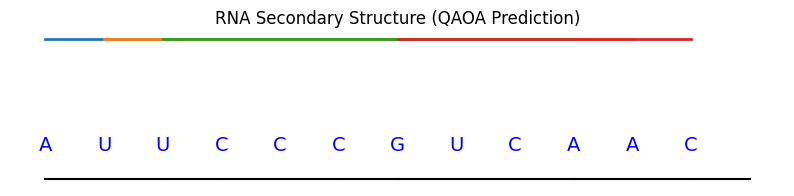

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,2))

# Draw RNA backbone
for i in range(len(rna)): # Changed 'length' to 'len(rna)'
    plt.plot([i, i+1], [0,0], color="black")

# Draw nucleotides
for i, base in enumerate(rna): # Changed 'sequence' to 'rna'
    plt.text(i, 0.05, base,
             fontsize=14,
             ha='center',
             color='blue')

# Draw base pairs found by QAOA
for i, j in selected_pairs_qaoa:
    plt.plot([i, j], [0.25, 0.25],
             linewidth=2)

plt.title("RNA Secondary Structure (QAOA Prediction)")
plt.axis("off")
plt.show()

In [33]:
print("="*60)
print("FINAL RESULT")
print("="*60)

print("RNA Sequence:")
print(rna)

print("\nViennaRNA Structure:")
print(structure)

print("\nViennaRNA Energy:")
print(mfe)

print("\nQAOA Energy:")
print(result.fval)

print("\nPredicted Base Pairs:")
print(selected_pairs_qaoa)

FINAL RESULT
RNA Sequence:
AUUCCCGUCAAC

ViennaRNA Structure:
............

ViennaRNA Energy:
0.0

QAOA Energy:
-4.0

Predicted Base Pairs:
[(0, 7), (1, 10), (2, 9), (6, 11)]


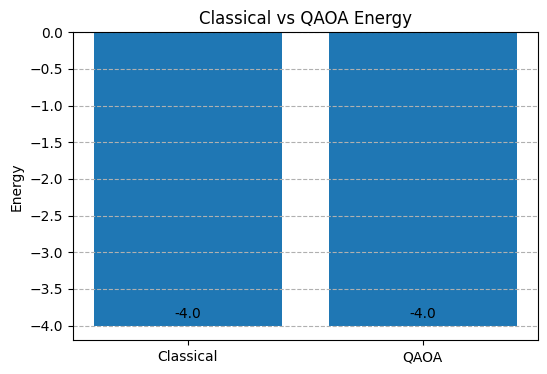

In [34]:
import matplotlib.pyplot as plt

methods = ["Classical", "QAOA"]
energies = [best_energy, result.fval]

plt.figure(figsize=(6,4))

plt.bar(methods, energies)

plt.title("Classical vs QAOA Energy")
plt.ylabel("Energy")

for i, v in enumerate(energies):
    plt.text(i, v + 0.1, str(v), ha="center")

plt.grid(axis="y", linestyle="--")

plt.show()

In [35]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Classical", "QAOA"],
    "Energy": [best_energy, result.fval]
})

results.to_csv("QAOA_Results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [36]:
print("="*60)
print("FINAL PROJECT REPORT")
print("="*60)

print("\nProject Title")
print("RNA Secondary Structure Optimization using QAOA")

print("\nObjective")
print("Optimize RNA secondary structure using a QUBO model and QAOA.")

print("\nMethodology")
print("1. Generated RNA sequence")
print("2. Generated possible base pairs")
print("3. Constructed QUBO matrix")
print("4. Solved classically")
print("5. Solved using QAOA")
print("6. Compared results")

print("\nResults")
print("Classical Energy :", best_energy)
print("QAOA Energy      :", result.fval)

print("\nBest Base Pairs")
print(selected_pairs)

print("\nQAOA Base Pairs")
print(selected_pairs_qaoa)

print("\nConclusion")
if result.fval <= best_energy:
    print("QAOA successfully found an optimal RNA folding solution.")
else:
    print("Classical optimization performed better.")

print("="*60)

FINAL PROJECT REPORT

Project Title
RNA Secondary Structure Optimization using QAOA

Objective
Optimize RNA secondary structure using a QUBO model and QAOA.

Methodology
1. Generated RNA sequence
2. Generated possible base pairs
3. Constructed QUBO matrix
4. Solved classically
5. Solved using QAOA
6. Compared results

Results
Classical Energy : -4.0
QAOA Energy      : -4.0

Best Base Pairs
[(0, 7), (1, 10), (2, 9), (6, 11)]

QAOA Base Pairs
[(0, 7), (1, 10), (2, 9), (6, 11)]

Conclusion
QAOA successfully found an optimal RNA folding solution.
